EDA on dataset


In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [10]:
df = pd.read_csv("train.csv")


In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [17]:
df.describe(include="object")

C:\Users\cgvak\AppData\Local\Temp\ipykernel_1752\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Missing Values

In [ ]:
#data-quality discovery
#check for the missing  values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
# or check the missing value by 

[feature for feature in df.columns if df[feature].isnull().sum() > 0]

['Age', 'Cabin', 'Embarked']

Missing value percentage 

In [21]:
missing_percentage = df.isnull().mean()*100

print(missing_percentage.sort_values(ascending=False))

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


Different ways to handle missing values

Missing Value
   
Remove or    Fill - >  Mean /  Median  /   Mode

imputation - > replacing missing or null values in a dataset with estimated or plausible values

There are three common choices:Mean
Median
Mode

Mode is much more natural for categorical data

What happens when there is an outlier - > the mean get afftected by the outlier 


| Situation                    | Common choice |
| ---------------------------- | ------------- |
| Numerical, roughly symmetric | **Mean**      |
| Numerical, skewed / outliers | **Median**    |
| Categorical                  | **Mode**      |


In [34]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [33]:
"""Therefore, median is a reasonable simple imputation choice because it represents
the center without being strongly influenced by unusually high or low ages.

so we use the median to replace null values here 
"""

df["Age"] = df["Age"].fillna(df["Age"].median())

print(df["Age"].isnull().sum())

0


In [ ]:
#next come the Embarked
""" 
it is a categorical data so we mostly likly go with the mode 
 """

#first will check the repertaions 
df["Embarked"].value_counts()


#so we will fill the data with S as using mode 
#the mode get retured as series so we use the index to get only the data 
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


print(df["Embarked"].isnull().sum())


0


In [ ]:
#next is the cabin 

df["Cabin"].head(20)

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

In [47]:
df["Cabin"].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [49]:
df["Cabin"].nunique()

147

so we are doing Feature Engineering as we make the cabin feature to create a new one 

In [ ]:
#created a new feature as cabinKnown or not 
df["CabinKnown"] = df["Cabin"].notnull().astype(int)

CabinKnown
0    0.299854
1    0.666667
Name: Survived, dtype: float64

duplicate Check and Unique Values


In [ ]:
#Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
""" if is case there is any duplicates then remove by as 

df = df.drop_duplicates() 
"""


In [ ]:
#check unique values
df["Sex"].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [54]:
#check the no of unique values 
df["Sex"].nunique()

2

In [55]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
CabinKnown       2
dtype: int64

value_counts() tells us how frequently each value occurs.

In [56]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [57]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

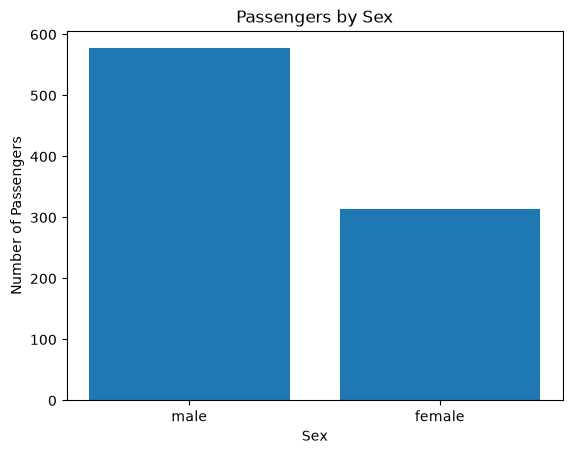

In [58]:
sex_count = df["Sex"].value_counts()

plt.bar(sex_count.index, sex_count.values)

plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.title("Passengers by Sex")

plt.show()